In [7]:
import os
import pickle
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import glob
import easyocr
import cv2
from imutils.video import FileVideoStream
from datetime import datetime, timedelta
from dbscan1d.core import DBSCAN1D

In [8]:
load_dotenv()

True

In [9]:
tracks_folder = os.environ.get("TRACKS_OUTPUT")

track_files = sorted(glob.glob(os.path.join(
    tracks_folder, f"2025-08-07-tracks-class-3-clip-*.pkl")))

In [10]:
tracks = {}
for i in range(len(track_files)):
    t = os.path.join(tracks_folder, f"{track_files[i]}")
    t1 = pickle.load(open(t, 'rb'))
    tracks[i] = t1

C:\Users\BDDea\AppData\Local\Temp\ipykernel_17708\3820125882.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  t1 = pickle.load(open(t, 'rb'))


In [11]:
def fish_mid(track):
    ''' 
    Returns midpoint of each fish at each time in each file

        Args:
            track (dict): gives fish with corresponding time stamps and location
                keys: tag number for fish
                values (dict): gives time stamps and location and size of bounding box
                    keys: time stamps (frame number)
                    values (list): top left coordinates of bounding box followed by the width and height of the box
        Returns:
            track (dict): same format as the parameter, only with xmidpoint for each bounding box
                keys: tag number for fish
                values (dict): gives time stamps and x midpoint of bounding box
                    keys: time stamps
                    values: x midpoint of bounding box
    '''
    for tag in track:
        for time in track[tag]:
            if len(track[tag][time]) == 4:
                x_min, y_min, width, height = track[tag][time]
                track[tag][time][0] = x_min + width/2
                # track[tag][time][1] = y_min + height/2
                track[tag][time] = track[tag][time][0].tolist()
    return track

In [12]:
for file in tracks:
    tracks[file] = fish_mid(tracks[file])

In [13]:
def crossing_times(tag, line, leftright):
    ''' 
    Returns the crossing time for a specified fish

        Parameters:
            tag (dict): gives coordinate for fish at respective time stamps
                keys: time stamp
                values: x midpoint for bounding box (from fish_mid function)
            line (int): x-value of vertical line for crossing
        Returns:
            times (list): list of frame count number to give times that fish crossed line
    '''
    times = []
    for time in tag:
        if time+1 in tag:
            if leftright == True:
                if tag[time] < line:
                    if tag[time+1] >= line:
                        times.append(time)
            else:
                if tag[time] >= line:
                    if tag[time+1] < line:
                        times.append(time)
    if times != []:
        return times


def file_fish_cross(tracks, line):
    ''' 
    Returns the files in which fish cross a vertical line

        Parameters:
            tracks (dict): gives file number, fish tag, time, and location for files
                keys: file number
                values (dict): fish tag numbers with respective time and x midpoint location
                    As given by fish_mid function.
                    keys: fish tag number
                    values (dict): x midpoint for each frame number
                        keys: frame number to give time
                        values: x-midpoint of boudning box
            line (int): x-value of vertical line for measuring crossing
        Returns:
            lr (dict): gives crossing times for each fish going left to right.
                keys: file number
                values (dict): gives fish and crossing time for each file 
                    keys: fish tag number
                    values (list): frame number for crossing times
            rl (dict):gives crossing times for each fish going right to left.
                keys: file number
                values (dict): gives fish and crossing time for each file 
                    keys: fish tag number
                    values (list): frame number for crossing times
    '''
    lr = {}
    rl = {}
    for file in tracks:
        for tag in tracks[file]:
            lr_crossing = crossing_times(
                tracks[file][tag], line=line, leftright=True)
            if lr_crossing:
                if file not in lr:
                    lr[file] = {}
                lr[file][tag] = lr_crossing
            rl_crossing = crossing_times(
                tracks[file][tag], line=line, leftright=False)
            if rl_crossing:
                if file not in rl:
                    rl[file] = {}
                rl[file][tag] = rl_crossing
    return lr, rl

In [14]:
left_right, right_left = file_fish_cross(tracks, 1500)

In [15]:
def dbscan_dist(direction_data, proximity):
    '''
    Uses DBSCAN1 to get fish groups of given direction data with specified proximity

        Args:
            direction_data (dict): fish tags with their respective crossing times for an entire day
                keys: fish tag number
                values: list of crossing times in seconds
            proximity (int): specifies how close in time classifies a group
        Returns:
            groups (list): list of all groups with their respective fish
    '''
    fishes = []
    all_times = []
    for fish, times in direction_data.items():
        for time in times:
            fishes.append(fish)
            all_times.append(time)
    all_times = np.array(all_times)
    dbs = DBSCAN1D(eps=proximity, min_samples=2)
    labels = dbs.fit_predict(all_times)
    groups = []
    for label in set(labels):
        if label == -1:
            continue
        group = []
        for i in range(len(labels)):
            if labels[i] == label:
                if fishes[i] not in group:
                    group.append(fishes[i])
        groups.append(group)
    return groups

In [16]:
lr_groupss = []
for file in left_right:
    groups = dbscan_dist(left_right[file], 45)
    if groups:
        lr_groupss.append(groups)

print(lr_groupss)

[[[5979]]]


In [55]:
left_right, right_left = file_fish_cross(tracks, 2200)

In [19]:
rl_groups = []
for file in right_left:
    if len(right_left[file]) == 1:
        continue
    groups = dbscan_dist(right_left[file], 45)
    if groups:
        rl_groups.append(groups)

print(rl_groups)

[[[5625, 5632]], [[5776, 5777, 5778, 5779], [5780, 5781]], [[5800, 5801], [5805, 5810], [5807], [5820, 5822]], [[5880, 5882, 5884], [5893, 5894]], [[5920, 5922, 5925], [5956, 5957]], [[5978, 5979], [5985, 5986]], [[5994, 5995]], [[6003, 6004]], [[6013, 6017]], [[6059, 6066]], [[6080, 6081]], [[6134, 6135]], [[6171, 6177]]]


1 sec, 3 sec, 9 sec

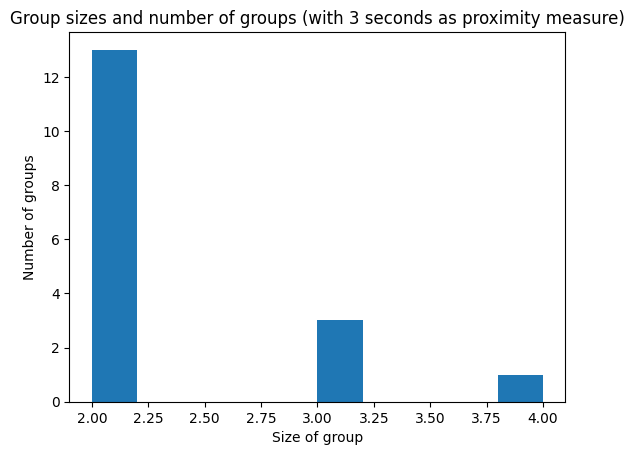

In [57]:
groups = []
for file in right_left:
    if len(right_left[file]) == 1:
        continue
    fishes = []
    all_times = []
    for fish, times in right_left[file].items():
        for time in times:
            fishes.append(fish)
            all_times.append(time)
    all_times = np.array(all_times)
    dbs = DBSCAN1D(eps=45, min_samples=2)
    labels = dbs.fit_predict(all_times)
    for label in set(labels):
        if label == -1:
            continue
        group = []
        for i in range(len(labels)):
            if labels[i] == label:
                if fishes[i] not in group:
                    group.append(fishes[i])
        if len(group) > 1:
            groups.append(group)

# for group in groups:
#     print(group)
histo = []
for group in groups:
    histo.append(len(group))

plt.hist(histo)
plt.title('Group sizes and number of groups (with 3 seconds as proximity measure)')
plt.xlabel('Size of group')
plt.ylabel('Number of groups')
plt.show()

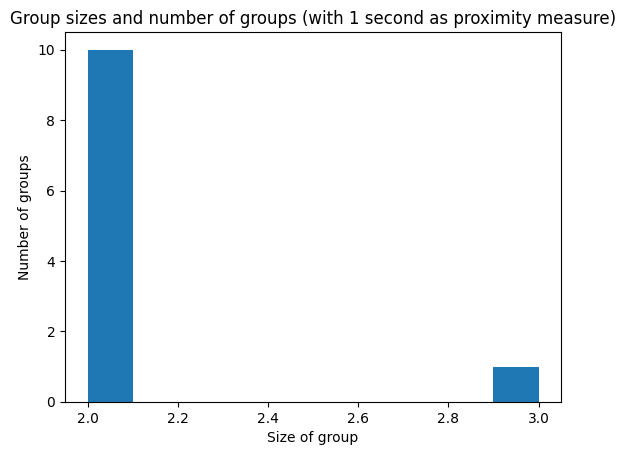

In [58]:
groups = []
for file in right_left:
    if len(right_left[file]) == 1:
        continue
    fishes = []
    all_times = []
    for fish, times in right_left[file].items():
        for time in times:
            fishes.append(fish)
            all_times.append(time)
    all_times = np.array(all_times)
    dbs = DBSCAN1D(eps=15, min_samples=2)
    labels = dbs.fit_predict(all_times)
    for label in set(labels):
        if label == -1:
            continue
        group = []
        for i in range(len(labels)):
            if labels[i] == label:
                if fishes[i] not in group:
                    group.append(fishes[i])
        if len(group) > 1:
            groups.append(group)

histo = []
for group in groups:
    histo.append(len(group))

plt.hist(histo)
plt.title('Group sizes and number of groups (with 1 second as proximity measure)')
plt.xlabel('Size of group')
plt.ylabel('Number of groups')
plt.show()

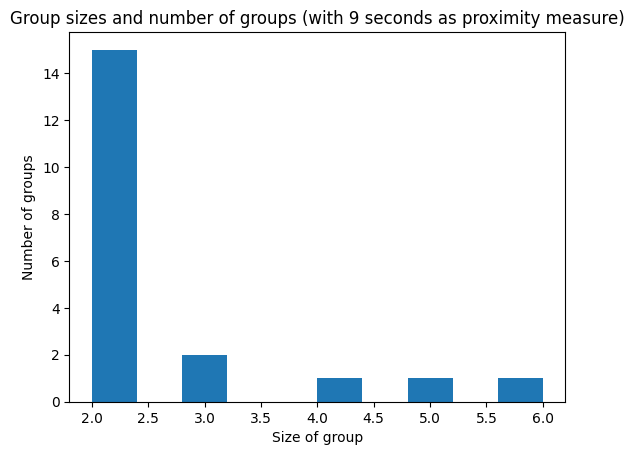

In [59]:
groups = []
for file in right_left:
    if len(right_left[file]) == 1:
        continue
    fishes = []
    all_times = []
    for fish, times in right_left[file].items():
        for time in times:
            fishes.append(fish)
            all_times.append(time)
    all_times = np.array(all_times)
    dbs = DBSCAN1D(eps=135, min_samples=2)
    labels = dbs.fit_predict(all_times)
    for label in set(labels):
        if label == -1:
            continue
        group = []
        for i in range(len(labels)):
            if labels[i] == label:
                if fishes[i] not in group:
                    group.append(fishes[i])
        if len(group) > 1:
            groups.append(group)

histo = []
for group in groups:
    histo.append(len(group))

plt.hist(histo)
plt.title('Group sizes and number of groups (with 9 seconds as proximity measure)')
plt.xlabel('Size of group')
plt.ylabel('Number of groups')
plt.show()